In [ ]:
import pandas as pd
import numpy as np
import sklearn
import random

In [ ]:
with open('NLP_project_unlabelled_slim.txt') as f:
    lines = f.readlines()

In [ ]:
climate_misclassified = pd.read_csv("climate_misclassified.csv")
sentiment_misclassified = pd.read_csv("sentiment_misclassified.csv")
specificity_misclassified = pd.read_csv("specificity_misclassified.csv")
commitment_misclassified = pd.read_csv("commitment_misclassified.csv")

In [ ]:
climate_misclassified

,text,label
0,"In this document, section 4.3.1.3 (1) Financin...",1
1,In the event that we identify any unlawful act...,1
2,Paper BlackRock set a 2020 paper reduction tar...,0
3,"64 exclusion lists of companies and countries,...",1
4,"In 2018, our Robo Investment Subsidiary Wealth...",0
5,Equator Principles (EP) within the scope cover...,0
6,Anticipated major impacts on the Group There a...,0
7,The global economic system as we know it is un...,1
8,"During 2019, we continued our focus on optimiz...",1
9,Creating value Measuring our reputation KPI FY...,1


In [ ]:
climate_misclassified["text"][3]

'64 exclusion lists of companies and countries, drawn up and updated periodically, with the help of an independent expert advisor. These lists include companies involved in controversial weapons and countries with high risk of violating human rights, which are automatically excluded from the list of companies in which BBVA can invest.'

In [ ]:
# Texts that are at least misclassified in one label

AllMisclassified = pd.concat([climate_misclassified, sentiment_misclassified, specificity_misclassified, commitment_misclassified])
AllMisclassified = AllMisclassified[["text"]].drop_duplicates()
AllMisclassified = AllMisclassified.reset_index(drop=True)
AllMisclassified

,text
0,"In this document, section 4.3.1.3 (1) Financin..."
1,In the event that we identify any unlawful act...
2,Paper BlackRock set a 2020 paper reduction tar...
3,"64 exclusion lists of companies and countries,..."
4,"In 2018, our Robo Investment Subsidiary Wealth..."
...,...
76,This project was achieved through collaboratio...
77,AGL Macquarie is working with WaterNSW to add ...
78,Screening Process for Loan and Investment Prop...
79,Capital Dynamics is a global private asset man...


# Define similarity metrics

In [ ]:
!pip install pywsd

import nltk
from nltk.corpus import PlaintextCorpusReader
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('omw-1.4')
nltk.download('punkt')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
!mkdir text_files

corpus_root = '/content/text_files'
corpus = PlaintextCorpusReader(corpus_root, '.*')
corpus.fileids()

[]

In [ ]:
# source: https://nlpforhackers.io/wordnet-sentence-similarity/

In [ ]:
from nltk import word_tokenize, pos_tag
from nltk.corpus import wordnet as wn
 
def penn_to_wn(tag):
    """ Convert between a Penn Treebank tag to a simplified Wordnet tag """
    if tag.startswith('N'):
        return 'n'
 
    if tag.startswith('V'):
        return 'v'
 
    if tag.startswith('J'):
        return 'a'
 
    if tag.startswith('R'):
        return 'r'
 
    return None
 
def tagged_to_synset(word, tag):
    wn_tag = penn_to_wn(tag)
    if wn_tag is None:
        return None
 
    try:
        return wn.synsets(word, wn_tag)[0]
    except:
        return None
 
def sentence_similarity(sentence1, sentence2):
    """ compute the sentence similarity using Wordnet """
    # Tokenize and tag
    sentence1 = pos_tag(word_tokenize(sentence1))
    sentence2 = pos_tag(word_tokenize(sentence2))
 
    # Get the synsets for the tagged words
    synsets1 = [tagged_to_synset(*tagged_word) for tagged_word in sentence1]
    synsets2 = [tagged_to_synset(*tagged_word) for tagged_word in sentence2]
 
    # Filter out the Nones
    synsets1 = [ss for ss in synsets1 if ss]
    synsets2 = [ss for ss in synsets2 if ss]
 
    score, count = 0.0, 0
 
    # For each word in the first sentence
    for synset in synsets1:
        # Get the similarity value of the most similar word in the other sentence
        best_score = max([synset.path_similarity(ss) for ss in synsets2])
 
        # Check that the similarity could have been computed
        if best_score is not None:
            score += best_score
            count += 1
 
    # Average the values
    score /= count
    return score
 
sentences = [
    "Dogs are awesome.",
    "Some gorgeous creatures are felines.",
    "Dolphins are swimming mammals.",
    "Cats are beautiful animals.",
]
 
focus_sentence = "Cats are beautiful animals."
 
for sentence in sentences:
    print("Similarity(\"%s\", \"%s\") = %s" % (focus_sentence, sentence, sentence_similarity(focus_sentence, sentence)))
    print("Similarity(\"%s\", \"%s\") = %s" % (sentence, focus_sentence, sentence_similarity(sentence, focus_sentence)))

 
# Similarity("Cats are beautiful animals.", "Dogs are awesome.") = 0.511111111111
# Similarity("Dogs are awesome.", "Cats are beautiful animals.") = 0.666666666667
 
# Similarity("Cats are beautiful animals.", "Some gorgeous creatures are felines.") = 0.833333333333
# Similarity("Some gorgeous creatures are felines.", "Cats are beautiful animals.") = 0.833333333333
 
# Similarity("Cats are beautiful animals.", "Dolphins are swimming mammals.") = 0.483333333333
# Similarity("Dolphins are swimming mammals.", "Cats are beautiful animals.") = 0.4
 
# Similarity("Cats are beautiful animals.", "Cats are beautiful animals.") = 1.0
# Similarity("Cats are beautiful animals.", "Cats are beautiful animals.") = 1.0
 

Similarity("Cats are beautiful animals.", "Dogs are awesome.") = 0.4666666666666666
Similarity("Dogs are awesome.", "Cats are beautiful animals.") = 0.5555555555555555
Similarity("Cats are beautiful animals.", "Some gorgeous creatures are felines.") = 0.7083333333333333
Similarity("Some gorgeous creatures are felines.", "Cats are beautiful animals.") = 0.7083333333333333
Similarity("Cats are beautiful animals.", "Dolphins are swimming mammals.") = 0.4458333333333333
Similarity("Dolphins are swimming mammals.", "Cats are beautiful animals.") = 0.4
Similarity("Cats are beautiful animals.", "Cats are beautiful animals.") = 1.0
Similarity("Cats are beautiful animals.", "Cats are beautiful animals.") = 1.0


In [ ]:
def symmetric_sentence_similarity(sentence1, sentence2):
    """ compute the symmetric sentence similarity using Wordnet """
    return (sentence_similarity(sentence1, sentence2) + sentence_similarity(sentence2, sentence1)) / 2 

#Look for similar paragraphs 


In [ ]:
AllMisclassified

,text
0,"In this document, section 4.3.1.3 (1) Financin..."
1,In the event that we identify any unlawful act...
2,Paper BlackRock set a 2020 paper reduction tar...
3,"64 exclusion lists of companies and countries,..."
4,"In 2018, our Robo Investment Subsidiary Wealth..."
...,...
76,This project was achieved through collaboratio...
77,AGL Macquarie is working with WaterNSW to add ...
78,Screening Process for Loan and Investment Prop...
79,Capital Dynamics is a global private asset man...


In [ ]:
n = 300
a_shape = (len(AllMisclassified["text"]), n)  # 81 rows and 300 columns
similarityMatrix = np.zeros(a_shape)
similarityMatrix.shape

(81, 300)

In [ ]:
index_value = random.sample(list(enumerate(lines)), n)
index_value

[(44983,
  'COVID-19 drives customer rewards program innovation Our Singapore shoppers’ rewards program and app, Lendlease Plus, launched several new COVID-19 stimulated offers in FY20 to the program’s approximately 128,000 members. This included new food delivery special offers with partners GrabFood, foodpanda and deliveroo, designed to support customers who did not want to leave home and provide indirect support to participating food and beverage retailers. Members could also donate reward dollars to Willing Hearts, a local meal delivery charity supporting people in need during the COVID-19 period.\n'),
 (20832,
  'For a further discussion of trends, uncertainties and other factors that could impact our operating results, see the section entitled "Risk Factors" in Item 1A, which is incorporated herein by reference.\n'),
 (83195,
  "Mr. Imaz has been delegated all functions of the Board of Directors, except for those that cannot be delegated by law or under the bylaws, is the Company

In [ ]:
indexes_list = []

for i in range(len(AllMisclassified["text"])):
  print("interation ", i, " start")
  values = []
  indexes = []
  index_value = random.sample(list(enumerate(lines)), n)
  for idx, val in index_value:
      indexes.append(idx)
      values.append(val)
  indexes_list.append(indexes)

  for j in range(n):
    similarity = symmetric_sentence_similarity(AllMisclassified["text"][i], values[j])
    similarityMatrix[i][j] = similarity

interation  0  start
interation  1  start
interation  2  start
interation  3  start
interation  4  start
interation  5  start
interation  6  start
interation  7  start
interation  8  start
interation  9  start
interation  10  start
interation  11  start
interation  12  start
interation  13  start
interation  14  start
interation  15  start
interation  16  start
interation  17  start
interation  18  start
interation  19  start
interation  20  start
interation  21  start
interation  22  start
interation  23  start
interation  24  start
interation  25  start
interation  26  start
interation  27  start
interation  28  start
interation  29  start
interation  30  start
interation  31  start
interation  32  start
interation  33  start
interation  34  start
interation  35  start
interation  36  start
interation  37  start
interation  38  start
interation  39  start
interation  40  start
interation  41  start
interation  42  start
interation  43  start
interation  44  start
interation  45  star

In [ ]:
maxIndex =[]
for i in similarityMatrix: 
  maxIndex.append(i.argsort()[-3:][::-1])

maxIndex

[array([299, 298, 297]),
 array([262, 171,  57]),
 array([148,   8,  29]),
 array([288, 239, 213]),
 array([ 33, 276, 272]),
 array([284, 231, 237]),
 array([223, 242,  68]),
 array([291,  46, 287]),
 array([179,  35, 147]),
 array([ 49, 272, 270]),
 array([ 79, 208, 198]),
 array([263, 121, 108]),
 array([157, 106, 145]),
 array([215,  99, 189]),
 array([82, 44, 31]),
 array([251, 133, 217]),
 array([ 45, 170,  71]),
 array([167, 222, 160]),
 array([  6, 139, 282]),
 array([155, 191, 292]),
 array([157, 298, 149]),
 array([  1,  28, 209]),
 array([180, 255,  96]),
 array([144, 250, 238]),
 array([ 36,   9, 231]),
 array([  5, 112,  55]),
 array([295, 120, 266]),
 array([ 39, 221,  78]),
 array([276,  45, 116]),
 array([154, 165, 102]),
 array([142,  69, 251]),
 array([96, 95, 77]),
 array([ 73, 275,  56]),
 array([229,  75, 272]),
 array([ 99, 277,  25]),
 array([ 15, 120, 189]),
 array([ 44,  61, 144]),
 array([ 36, 292, 113]),
 array([242,  75, 255]),
 array([ 79, 253, 283]),
 array

In [ ]:
maxValue =[]
for i in similarityMatrix: 
  maxValue.append(sorted(i)[-3:][::-1][0])

sorted(maxValue) # highest similarity score for each sentences 

[0.33072178879801384,
 0.33855018438351764,
 0.34184856343947245,
 0.3435504740414784,
 0.3479367525420157,
 0.3497422138047137,
 0.3550934515220229,
 0.36394124278499296,
 0.3655024951899952,
 0.3670526354736881,
 0.36771400410289296,
 0.367778379028379,
 0.3687698978581333,
 0.37180413308462085,
 0.37260333752269237,
 0.3744350196460586,
 0.37449792342265475,
 0.37486813111813116,
 0.3753932178932178,
 0.3755837007849392,
 0.376347422670952,
 0.3763531725366834,
 0.3823330952025534,
 0.38317885452753897,
 0.38319926986593644,
 0.38471419123204836,
 0.38494430104758737,
 0.3852065826330532,
 0.3867685472257706,
 0.3879936218752008,
 0.3885940979885079,
 0.388653105721793,
 0.39098793481849325,
 0.3909936095650381,
 0.3931089501327596,
 0.3933256765008143,
 0.3947854752170228,
 0.39660432160432146,
 0.39661984427609426,
 0.3980118013889944,
 0.39934639902060104,
 0.4010826673326673,
 0.4018105703819988,
 0.40768773165831984,
 0.40788793103448273,
 0.4091174348527289,
 0.410332863357916

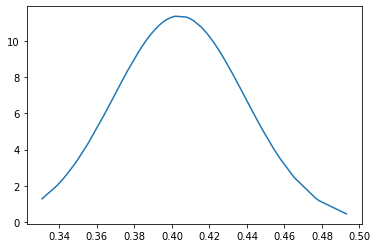

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import statistics
    
# Calculating mean and standard 
# deviation
mean = statistics.mean(sorted(maxValue))
sd = statistics.stdev(sorted(maxValue))

# check if the similarity scores has outliers 
plt.plot(sorted(maxValue), norm.pdf(sorted(maxValue), mean, sd))
plt.show()

In [ ]:
# look for the most similar text

realIndex = []
for ind, val in enumerate(maxIndex): # ind: 0, 1, 2, ..., 81 val: [92, 216], [233,54], [ , ] 
  for i in val: 
    realIndex.append(indexes_list[ind][i])

similarText = []
for j in realIndex: 
  similarText.append(lines[j])

similarText

['This is a free translation into English of a report issued in the French language and is provided solely for the convenience of English- speaking readers. This report should be read in conjunction with, and construed in accordance with, French law and professional standards applicable in France.\n',
 'We do not take our distinctive culture for granted. In 2014, we will continue to embed the Code and maintain a systematic approach to reinforcing our culture and values, while ensuring that our people have a safe and transparent means of raising issues. We will align our reward practices further in response to continued regulatory change. We will continue to remove unnecessary complexity, simplifying our policies and processes, and creating clearer responsibilities and accountabilities as we embed the new business structure. We will also continue to review our selection processes for managers and senior leaders, and refresh our training to help our employees understand how all of our po

In [ ]:
similarText_df = pd.DataFrame(similarText, columns = ['text'])
similarText_df

,text
0,This is a free translation into English of a r...
1,We do not take our distinctive culture for gra...
2,Dentistry • Arestin® (minocycline hydrochlorid...
3,Accounting Policy Provisions are recognised wh...
4,"The new framework, which includes measures to ..."
...,...
238,ECLs are recognised in two stages. - For credi...
239,"In the UK, we note that there is no alignment ..."
240,(1 ) The renter’s monthly payment includes the...
241,'There are risks and uncertainties that may ca...


In [ ]:
# check if there are duplications in these text

similarText_df = similarText_df.drop_duplicates()
similarText_df.reset_index(inplace=True)
similarText_df = similarText_df[["text"]]
similarText_df

,text
0,This is a free translation into English of a r...
1,We do not take our distinctive culture for gra...
2,Dentistry • Arestin® (minocycline hydrochlorid...
3,Accounting Policy Provisions are recognised wh...
4,"The new framework, which includes measures to ..."
...,...
238,ECLs are recognised in two stages. - For credi...
239,"In the UK, we note that there is no alignment ..."
240,(1 ) The renter’s monthly payment includes the...
241,'There are risks and uncertainties that may ca...


In [ ]:
similarText_df.to_csv("all_similar_text_top3_random.csv", encoding='utf_8_sig')

In [ ]:
similarText_df.to_excel("all_similar_text_top3_random.xlsx",
             sheet_name='Sheet_1')  
files.download("all_similar_text_top3_random.xlsx") 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
similarityMatrix

array([[0.25478309, 0.23446442, 0.27654267, ..., 0.25634302, 0.28882023,
        0.29786144],
       [0.20405554, 0.27160351, 0.31076806, ..., 0.250142  , 0.19302579,
        0.23975529],
       [0.23702826, 0.18841648, 0.24633458, ..., 0.24685437, 0.20828927,
        0.17646238],
       ...,
       [0.30082506, 0.21072166, 0.22241424, ..., 0.2251206 , 0.26283674,
        0.37587345],
       [0.21175379, 0.26095938, 0.28650393, ..., 0.2531255 , 0.26302969,
        0.23169619],
       [0.33617364, 0.18611002, 0.21393325, ..., 0.28264463, 0.21548907,
        0.24919406]])

In [ ]:
np.savetxt('similarityMatrix_random.csv',similarityMatrix,delimiter=",")

In [ ]:
from google.colab import files
files.download('similarityMatrix_random.csv') 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("all_similar_text_top3_random.csv") 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
d = pd.read_csv("all_similar_text_top3_random_rightencoding.csv", encoding='utf_8_sig')
d

,Unnamed: 0,text
0,0,This is a free translation into English of a r...
1,1,We do not take our distinctive culture for gra...
2,2,Dentistry • Arestin® (minocycline hydrochlorid...
3,3,Accounting Policy Provisions are recognised wh...
4,4,"The new framework, which includes measures to ..."
...,...,...
238,238,ECLs are recognised in two stages. - For credi...
239,239,"In the UK, we note that there is no alignment ..."
240,240,(1 ) The renter’s monthly payment includes the...
241,241,'There are risks and uncertainties that may ca...
